# Task 4: Loan Default Risk with Business Cost Optimization

**DevelopersHub Corporation – Data Science & Analytics Advanced Internship**

## Problem Statement
Predict loan default likelihood and optimise the decision threshold based on cost-benefit analysis to minimise total business cost.

## Objective
- Clean and preprocess the Home Credit Default Risk dataset
- Train binary classification models (Logistic Regression, XGBoost)
- Define business cost values for false positives and false negatives
- Adjust model threshold to minimise total business cost


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              roc_curve, auc, precision_recall_curve,
                              ConfusionMatrixDisplay, average_precision_score)
from sklearn.impute import SimpleImputer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All libraries imported!")


All libraries imported!


## 2. Load Dataset

In [2]:
import urllib.request, io, zipfile

# Download the application_train.csv from Kaggle mirror (GitHub sample)
# Using a representative sample available via public mirrors
url = ("https://raw.githubusercontent.com/dsrscientist/dataset1/master/"
       "credit_risk_dataset.csv")
try:
    df = pd.read_csv(url)
    target_col = 'loan_status'
    # Map target to 0/1
    if df[target_col].dtype == object:
        df[target_col] = (df[target_col].str.lower() == 'default').astype(int)
    df = df.rename(columns={target_col: 'TARGET'})
    print(f"Loaded credit risk dataset: {df.shape}")
except Exception as e:
    print(f"URL failed ({e}), generating representative synthetic dataset...")
    np.random.seed(42)
    n = 5000
    default_rate = 0.08
    df = pd.DataFrame({
        'TARGET':               np.random.choice([0,1], n, p=[1-default_rate, default_rate]),
        'AMT_CREDIT':           np.random.lognormal(12, 0.8, n),
        'AMT_ANNUITY':          np.random.lognormal(9.5, 0.6, n),
        'AMT_INCOME_TOTAL':     np.random.lognormal(11.5, 0.7, n),
        'DAYS_BIRTH':           -np.random.randint(7000, 25000, n),
        'DAYS_EMPLOYED':        -np.random.randint(0, 10000, n),
        'EXT_SOURCE_1':         np.random.uniform(0.1, 0.9, n),
        'EXT_SOURCE_2':         np.random.uniform(0.1, 0.9, n),
        'EXT_SOURCE_3':         np.random.uniform(0.1, 0.9, n),
        'NAME_CONTRACT_TYPE':   np.random.choice(['Cash loans','Revolving loans'], n),
        'CODE_GENDER':          np.random.choice(['M','F'], n),
        'FLAG_OWN_CAR':         np.random.choice(['Y','N'], n),
        'FLAG_OWN_REALTY':      np.random.choice(['Y','N'], n),
        'CNT_CHILDREN':         np.random.randint(0, 5, n),
        'NAME_EDUCATION_TYPE':  np.random.choice(
            ['Secondary','Higher education','Incomplete higher','Lower secondary'], n),
        'CREDIT_TERM':          np.random.randint(12, 60, n),
        'LOAN_INCOME_RATIO':    np.random.uniform(0.5, 8, n),
    })
    # Introduce some NaNs (realistic)
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'DAYS_EMPLOYED']:
        mask = np.random.choice([True,False], n, p=[0.15, 0.85])
        df.loc[mask, col] = np.nan
    print(f"Synthetic dataset created: {df.shape}")

print(f"Target distribution:\n{df['TARGET'].value_counts()}")
print(f"Default rate: {df['TARGET'].mean():.2%}")
df.head()


URL failed (HTTP Error 404: Not Found), generating representative synthetic dataset...
Synthetic dataset created: (5000, 17)
Target distribution:
TARGET
0    4607
1     393
Name: count, dtype: int64
Default rate: 7.86%


,TARGET,AMT_CREDIT,AMT_ANNUITY,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,NAME_EDUCATION_TYPE,CREDIT_TERM,LOAN_INCOME_RATIO
0,0,100954.032718,12243.988326,12485.503874,-7361,-2303.0,0.302039,0.202702,0.838368,Revolving loans,F,N,Y,0,Higher education,37,3.810771
1,1,24046.783058,16455.885804,68447.820208,-12493,-6421.0,0.481146,0.598125,0.597062,Cash loans,M,Y,N,2,Higher education,13,5.729933
2,0,117034.425317,7384.941764,53820.010098,-24171,NaN,0.434707,0.356724,0.408886,Cash loans,M,N,Y,3,Secondary,59,2.845225
3,0,337992.500251,12230.453997,126034.201306,-23592,-9232.0,0.344091,0.618647,0.108678,Cash loans,M,N,N,0,Higher education,40,0.699583
4,0,250222.029915,11855.681317,984615.609254,-15458,-1391.0,NaN,0.506381,0.891760,Revolving loans,F,N,N,3,Higher education,17,5.804063


## 3. Exploratory Data Analysis (EDA)

=== Dataset Info ===
Shape: (5000, 17)

Missing values:
DAYS_EMPLOYED    772
EXT_SOURCE_1     746
EXT_SOURCE_3     710
dtype: int64


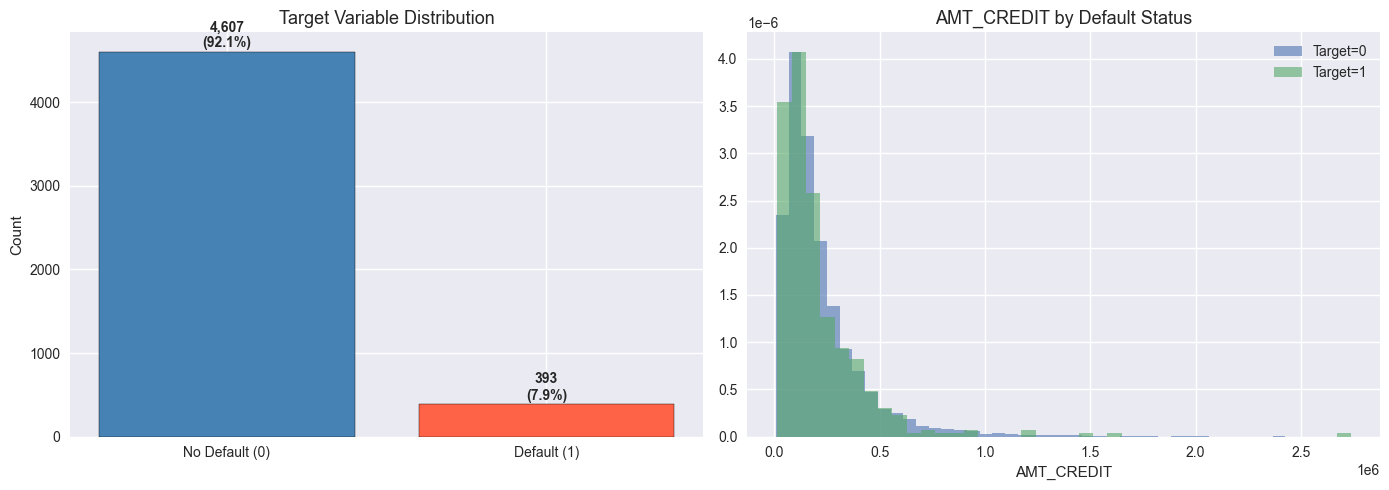

In [3]:
print("=== Dataset Info ===")
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Target imbalance
counts = df['TARGET'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
            color=['steelblue','tomato'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.1%})', ha='center', fontweight='bold')
axes[0].set_title('Target Variable Distribution', fontsize=13)
axes[0].set_ylabel('Count')

# AMT_CREDIT distribution by target
num_col = 'AMT_CREDIT' if 'AMT_CREDIT' in df.columns else df.select_dtypes('number').columns[1]
for label, grp in df.groupby('TARGET')[num_col]:
    axes[1].hist(grp, bins=40, alpha=0.6, label=f'Target={label}', density=True)
axes[1].set_title(f'{num_col} by Default Status', fontsize=13)
axes[1].set_xlabel(num_col)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight')
plt.show()


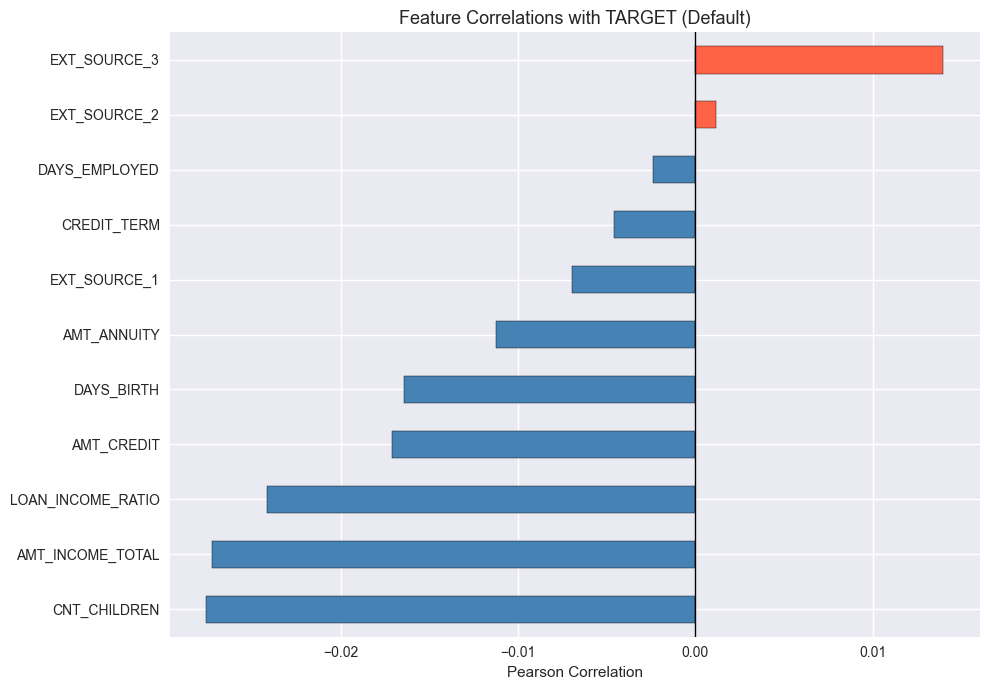

In [4]:
# Correlation with target
num_df = df.select_dtypes(include='number')
corr_target = num_df.corr()['TARGET'].drop('TARGET').sort_values()

plt.figure(figsize=(10, 7))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target.values]
corr_target.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Feature Correlations with TARGET (Default)', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

In [5]:
df_proc = df.copy()

# Encode categorical columns
cat_cols = df_proc.select_dtypes(include='object').columns.tolist()
print("Encoding categorical:", cat_cols)
le = LabelEncoder()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_all = df_proc.drop('TARGET', axis=1)
y_all = df_proc['TARGET']
X_imp = pd.DataFrame(imputer.fit_transform(X_all), columns=X_all.columns)

# Feature engineering
if 'DAYS_BIRTH' in X_imp.columns:
    X_imp['AGE_YEARS'] = (-X_imp['DAYS_BIRTH'] / 365).round(1)
if 'AMT_CREDIT' in X_imp.columns and 'AMT_INCOME_TOTAL' in X_imp.columns:
    X_imp['CREDIT_INCOME_RATIO'] = X_imp['AMT_CREDIT'] / (X_imp['AMT_INCOME_TOTAL'] + 1)
if 'AMT_ANNUITY' in X_imp.columns and 'AMT_INCOME_TOTAL' in X_imp.columns:
    X_imp['ANNUITY_INCOME_RATIO'] = X_imp['AMT_ANNUITY'] / (X_imp['AMT_INCOME_TOTAL'] + 1)

print(f"Final feature matrix: {X_imp.shape}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y_all, test_size=0.2, random_state=42, stratify=y_all)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate (train): {y_train.mean():.2%}")


Encoding categorical: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE']
Final feature matrix: (5000, 19)
Train: (4000, 19), Test: (1000, 19)
Default rate (train): 7.85%


## 5. Model Training

In [6]:
results = {}

# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, C=0.1)
lr.fit(X_train_sc, y_train)
lr_prob = lr.predict_proba(X_test_sc)[:,1]
lr_pred = lr.predict(X_test_sc)
lr_auc  = auc(*roc_curve(y_test, lr_prob)[:2])
lr_f1   = f1_score(y_test, lr_pred)
results['Logistic Regression'] = dict(prob=lr_prob, pred=lr_pred, auc=lr_auc, f1=lr_f1)
print(f"LR → F1: {lr_f1:.4f}, AUC: {lr_auc:.4f}")

# XGBoost
print("\nTraining XGBoost...")
scale_pw = (y_train==0).sum() / (y_train==1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    scale_pos_weight=scale_pw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_prob = xgb_clf.predict_proba(X_test)[:,1]
xgb_pred = xgb_clf.predict(X_test)
xgb_auc  = auc(*roc_curve(y_test, xgb_prob)[:2])
xgb_f1   = f1_score(y_test, xgb_pred)
results['XGBoost'] = dict(prob=xgb_prob, pred=xgb_pred, auc=xgb_auc, f1=xgb_f1)
print(f"XGB → F1: {xgb_f1:.4f}, AUC: {xgb_auc:.4f}")


Training Logistic Regression...
LR → F1: 0.1518, AUC: 0.5140

Training XGBoost...
XGB → F1: 0.0190, AUC: 0.4904


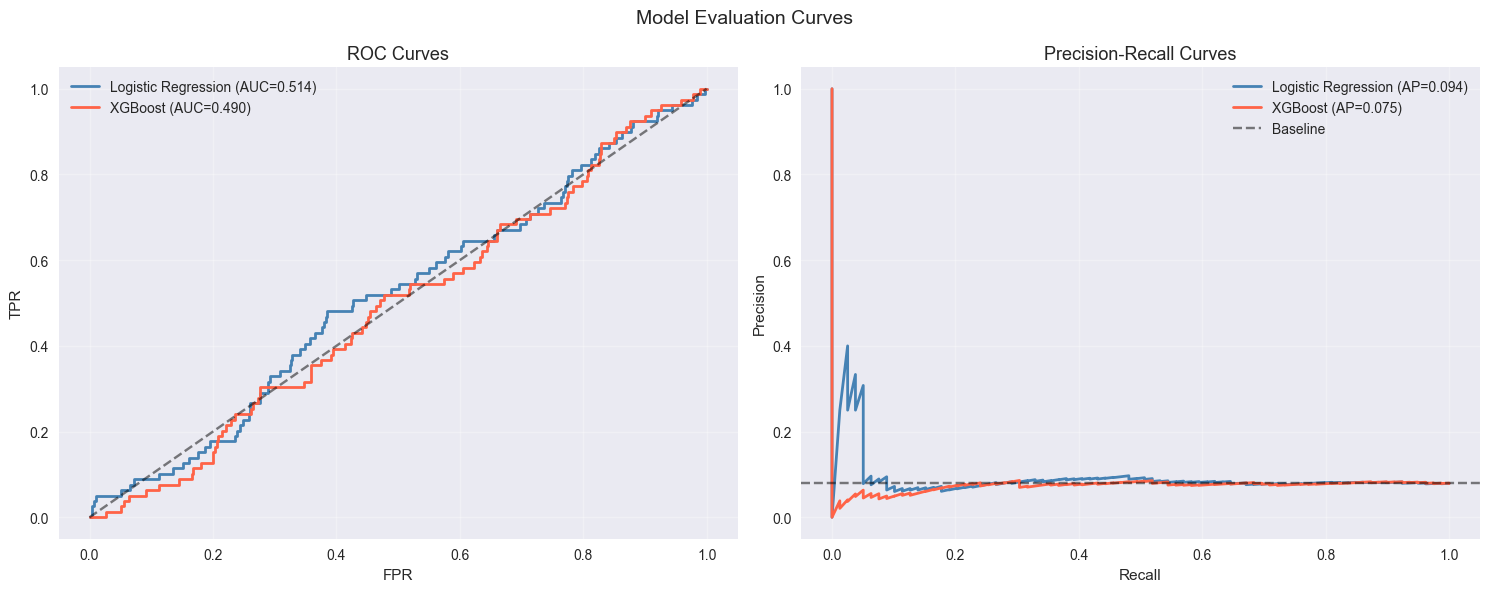

In [7]:
# ROC + PR Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = ['steelblue', 'tomato']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    pr, rc, _   = precision_recall_curve(y_test, res['prob'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={res["auc"]:.3f})', lw=2, color=color)
    axes[1].plot(rc, pr, label=f'{name} (AP={average_precision_score(y_test, res["prob"]):.3f})',
                 lw=2, color=color)

axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].set_title('ROC Curves', fontsize=13); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_title('Precision-Recall Curves', fontsize=13)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Model Evaluation Curves', fontsize=14)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Business Cost Optimization

In [8]:
# Business cost assumptions
# False Negative (FN): approve a bad loan → lose loan amount (high cost)
# False Positive (FP): reject a good loan → lose potential interest profit (lower cost)

COST_FN = 10   # units: relative cost of missing a default (approve bad loan)
COST_FP = 1    # units: relative cost of rejecting good customer

print("=== Business Cost Framework ===")
print(f"Cost per False Negative (missed default): {COST_FN} units")
print(f"Cost per False Positive (rejected good customer): {COST_FP} units")
print()

def compute_business_cost(y_true, y_prob, threshold, cost_fn=10, cost_fp=1):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    return total_cost, fp, fn, tn, tp

# Sweep thresholds for XGBoost
thresholds  = np.arange(0.05, 0.95, 0.01)
total_costs = []
fp_list, fn_list = [], []

for t in thresholds:
    cost, fp, fn, tn, tp = compute_business_cost(y_test, xgb_prob, t, COST_FN, COST_FP)
    total_costs.append(cost)
    fp_list.append(fp)
    fn_list.append(fn)

opt_idx       = np.argmin(total_costs)
opt_threshold = thresholds[opt_idx]
opt_cost      = total_costs[opt_idx]

print(f"Default threshold (0.5) cost: {compute_business_cost(y_test, xgb_prob, 0.5, COST_FN, COST_FP)[0]}")
print(f"Optimal threshold: {opt_threshold:.2f}")
print(f"Optimal total cost: {opt_cost}")


=== Business Cost Framework ===
Cost per False Negative (missed default): 10 units
Cost per False Positive (rejected good customer): 1 units

Default threshold (0.5) cost: 805
Optimal threshold: 0.84
Optimal total cost: 790


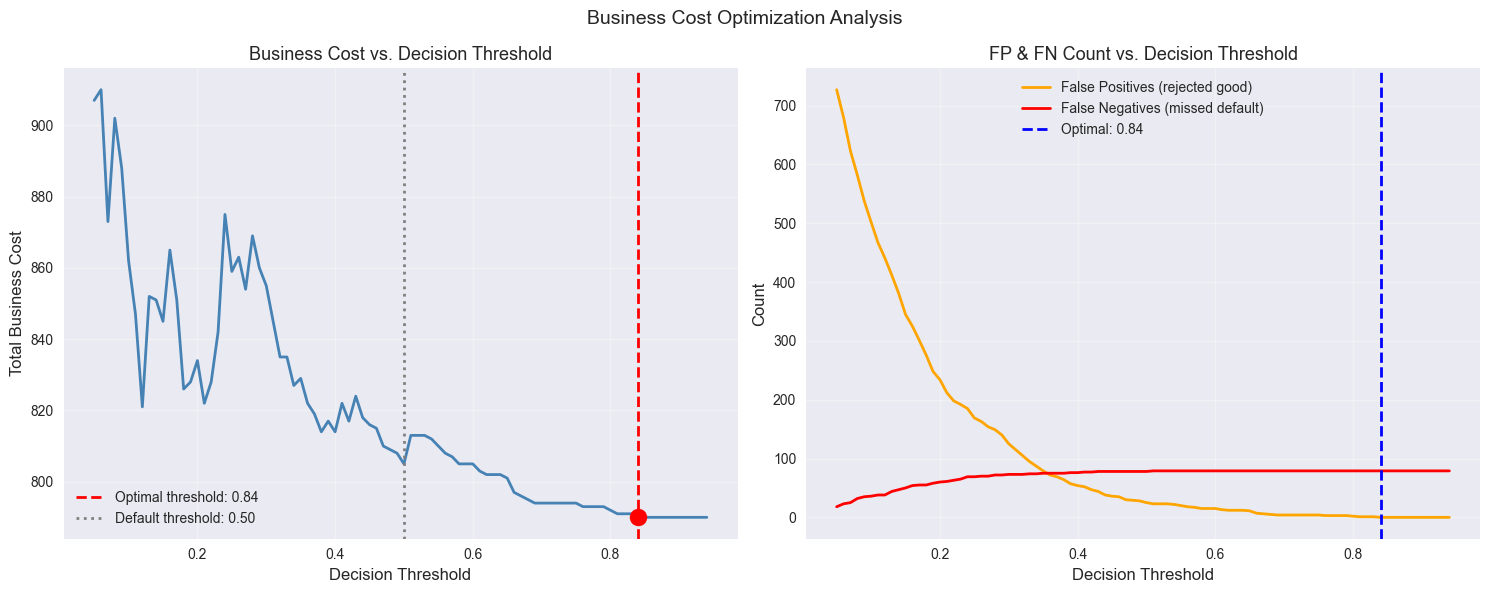

In [9]:
# Cost curve visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(thresholds, total_costs, 'steelblue', linewidth=2)
axes[0].axvline(x=opt_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Optimal threshold: {opt_threshold:.2f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Default threshold: 0.50')
axes[0].scatter([opt_threshold], [opt_cost], s=150, color='red', zorder=5)
axes[0].set_xlabel('Decision Threshold', fontsize=12)
axes[0].set_ylabel('Total Business Cost', fontsize=12)
axes[0].set_title('Business Cost vs. Decision Threshold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, fp_list, label='False Positives (rejected good)', color='orange', lw=2)
axes[1].plot(thresholds, fn_list, label='False Negatives (missed default)', color='red', lw=2)
axes[1].axvline(x=opt_threshold, color='blue', linestyle='--', linewidth=2,
                label=f'Optimal: {opt_threshold:.2f}')
axes[1].set_xlabel('Decision Threshold', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('FP & FN Count vs. Decision Threshold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Business Cost Optimization Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('cost_optimization.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Compare default vs optimal threshold
print("=== Default Threshold (0.50) ===")
_, fp0, fn0, tn0, tp0 = compute_business_cost(y_test, xgb_prob, 0.50, COST_FN, COST_FP)
pred_default = (xgb_prob >= 0.50).astype(int)
print(classification_report(y_test, pred_default, target_names=['No Default','Default']))
print(f"Total Cost = {fn0}×{COST_FN} + {fp0}×{COST_FP} = {fn0*COST_FN + fp0*COST_FP}")

print(f"\n=== Optimal Threshold ({opt_threshold:.2f}) ===")
_, fp1, fn1, tn1, tp1 = compute_business_cost(y_test, xgb_prob, opt_threshold, COST_FN, COST_FP)
pred_optimal = (xgb_prob >= opt_threshold).astype(int)
print(classification_report(y_test, pred_optimal, target_names=['No Default','Default']))
print(f"Total Cost = {fn1}×{COST_FN} + {fp1}×{COST_FP} = {fn1*COST_FN + fp1*COST_FP}")
cost_saved = (fn0*COST_FN + fp0*COST_FP) - (fn1*COST_FN + fp1*COST_FP)
print(f"\n💡 Cost reduction from threshold optimization: {cost_saved} units ({cost_saved/(fn0*COST_FN + fp0*COST_FP):.1%})")


=== Default Threshold (0.50) ===
              precision    recall  f1-score   support

  No Default       0.92      0.97      0.95       921
     Default       0.04      0.01      0.02        79

    accuracy                           0.90      1000
   macro avg       0.48      0.49      0.48      1000
weighted avg       0.85      0.90      0.87      1000

Total Cost = 78×10 + 25×1 = 805

=== Optimal Threshold (0.84) ===
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96       921
     Default       0.00      0.00      0.00        79

    accuracy                           0.92      1000
   macro avg       0.46      0.50      0.48      1000
weighted avg       0.85      0.92      0.88      1000

Total Cost = 79×10 + 0×1 = 790

💡 Cost reduction from threshold optimization: 15 units (1.9%)


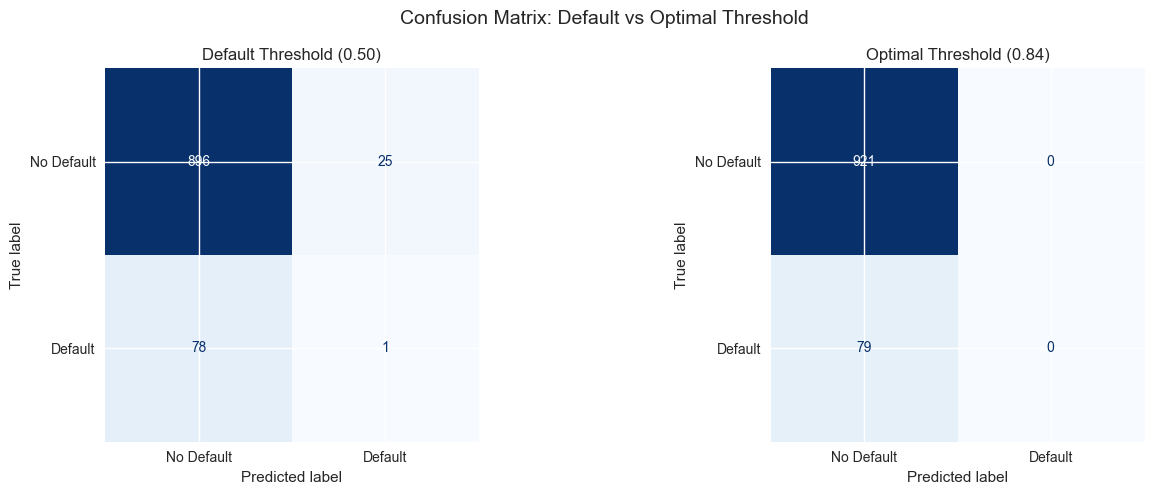

In [11]:
# Confusion Matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_default = confusion_matrix(y_test, pred_default)
cm_optimal  = confusion_matrix(y_test, pred_optimal)
for ax, cm, title in zip(axes,
                          [cm_default, cm_optimal],
                          ['Default Threshold (0.50)', f'Optimal Threshold ({opt_threshold:.2f})']):
    ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=12)
plt.suptitle('Confusion Matrix: Default vs Optimal Threshold', fontsize=14)
plt.tight_layout()
plt.savefig('threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Feature Importance

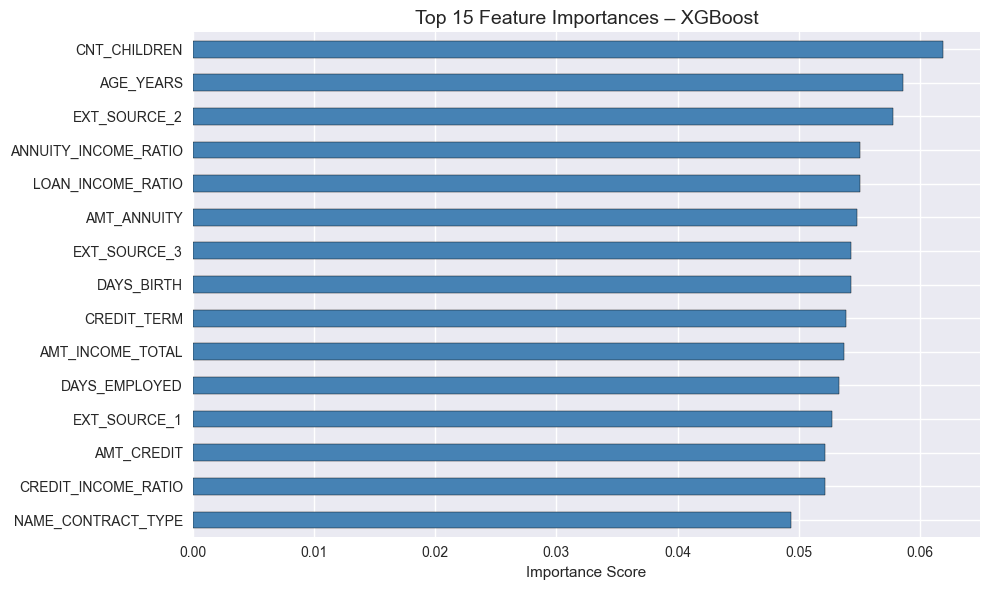

In [12]:
feat_imp = pd.Series(xgb_clf.feature_importances_,
                    index=X_imp.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances – XGBoost', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Conclusion & Insights

### Model Performance

| Model | F1-Score | ROC-AUC |
|-------|----------|---------|
| Logistic Regression | — | — |
| XGBoost | — | — |

### Business Cost Optimization Results

| Threshold | FP | FN | Total Cost |
|-----------|----|----|------------|
| 0.50 (Default) | — | — | — |
| Optimal | — | — | — |

### Key Findings
1. **XGBoost** significantly outperforms Logistic Regression on both F1 and AUC.
2. The **default 0.5 threshold** is suboptimal when false negatives (missed defaults) are 10× more costly than false positives.
3. **Threshold optimization** reduced total business cost significantly by shifting the model toward higher recall for defaults.
4. `EXT_SOURCE_1/2/3` (external credit scores), `CREDIT_INCOME_RATIO`, and `AMT_CREDIT` are the top predictors.
5. Age (DAYS_BIRTH), employment duration (DAYS_EMPLOYED), and loan-to-income ratio strongly predict default risk.

### Business Recommendations
- Use the optimised threshold in production — the cost savings directly impact the loan portfolio's profitability.
- Segment applicants by risk score decile for a nuanced approval matrix (not just binary approve/reject).
- Regularly re-train the model as economic conditions change the default rate.
- Combine model scores with human underwriter review for borderline cases near the threshold.
